In [1]:
suppressPackageStartupMessages({
    library(tidyr)
    library(ggplot2)
    library(ggrastr)
    library(viridis)
    library(data.table)
    library(gridExtra)
    library(SingleCellExperiment)
})


In [2]:
io = list()
io$haem_landscape = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/mapping_ivan'

haem_full_landscape = readRDS(file.path(io$haem_landscape, "haem_full_landscape.rds"))

In [4]:
io$biomart = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt'
biomart = fread(io$biomart)[match(rownames(haem_full_landscape), ens_id)]

In [5]:
rownames(haem_full_landscape) = biomart$symbol

In [6]:
haem_full_landscape_meta = as.data.table(colData(haem_full_landscape))
haem_full_landscape_meta$Eomes = as.vector(logcounts(haem_full_landscape['Eomes',]))
# Order by Eomes expression
haem_full_landscape_meta = haem_full_landscape_meta[order(Eomes)]

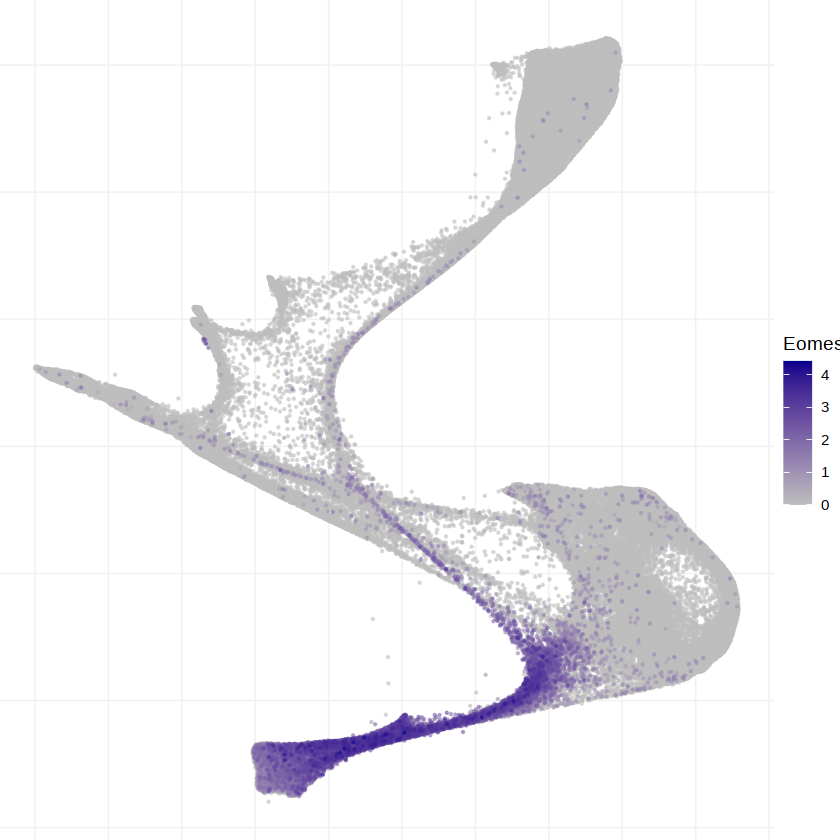

In [7]:
p = ggplot(haem_full_landscape_meta, aes(Dim1, Dim2, col=Eomes)) + 
        geom_point(size=0.2, alpha = 0.5) +
        scale_colour_gradient(low='grey', high='darkblue', name='Eomes') + 
        theme_void() +
        theme(panel.grid = element_line(color='grey95'))
p

In [67]:
pdf('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/results/eomes_haem.pdf', width=8, height=8)
    p
dev.off()

png 
  2

In [11]:
plot_gene = function(gene){
    haem_full_landscape_meta = as.data.table(colData(haem_full_landscape))
    haem_full_landscape_meta$gene = as.vector(logcounts(haem_full_landscape[gene,]))
    # Order by Eomes expression
    haem_full_landscape_meta = haem_full_landscape_meta[order(gene)]

    p = ggplot(haem_full_landscape_meta, aes(Dim1, Dim2, col=gene)) + 
            geom_point(size=0.2, alpha = 0.5) +
            scale_colour_gradient(low='grey', high='darkblue', name=gene) + 
            ggtitle(gene) + 
            theme_void() +
            theme(panel.grid = element_line(color='grey95'))
    p
}

In [14]:
gene_list = c('Etv2', 'Cd24a', 'Mfap2', 'Nnat', 'Lsr', 'Slc16a3', 'Ptn',  # EP endo
              'Lyve1', 'Clec14a', 'Stab2', 'Fmo1', 'Gap43', 'Gpr182', 'Npl') # YS endo

In [15]:
for(i in gene_list){
    pdf(sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/results/%s_haem.pdf', i), width=8, height=8)
        print(plot_gene(i))
    dev.off()
}

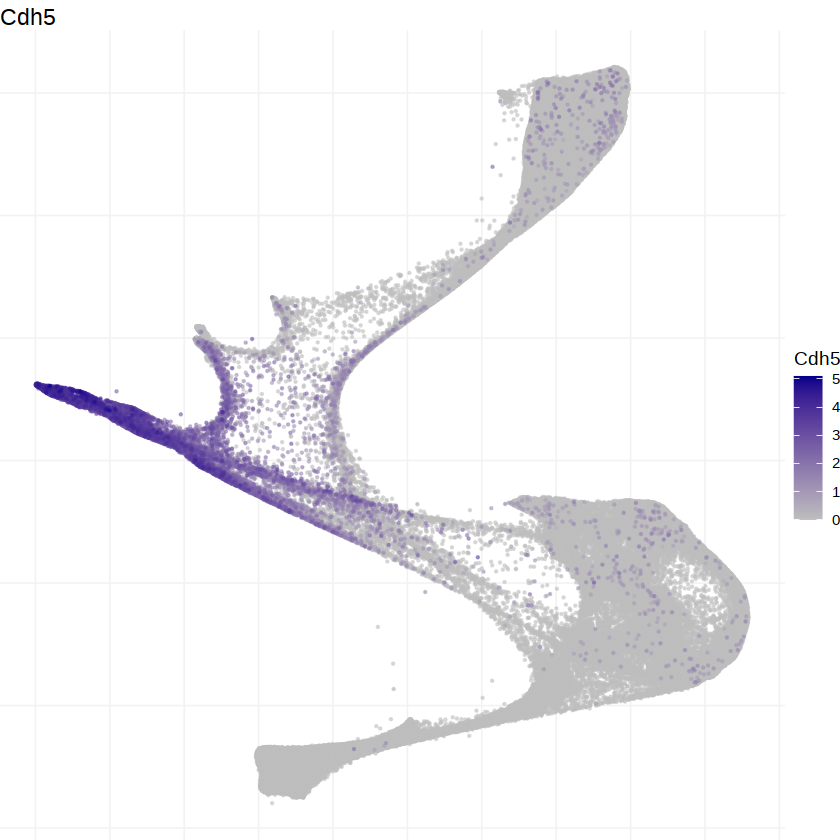

In [16]:
plot_gene('Cdh5')